/var/folders/n2/4bsv95vs6x7gd_mllf2ytv6m0000gn/T/ipykernel_13477/426137280.py:76: RuntimeWarning: All-NaN slice encountered
  corrs = np.nanmedian(corrs, 0)
/var/folders/n2/4bsv95vs6x7gd_mllf2ytv6m0000gn/T/ipykernel_13477/426137280.py:77: RuntimeWarning: All-NaN slice encountered
  shcs_nt = np.nanmedian(shcs_nt, 0)
/var/folders/n2/4bsv95vs6x7gd_mllf2ytv6m0000gn/T/ipykernel_13477/426137280.py:78: RuntimeWarning: All-NaN slice encountered
  shcs_nt_next = np.nanmedian(shcs_nt_next, 0)
/var/folders/n2/4bsv95vs6x7gd_mllf2ytv6m0000gn/T/ipykernel_13477/426137280.py:80: RuntimeWarning: invalid value encountered in sqrt
  corrs = corrs / np.sqrt(spearmanbrown_correction(shcs_nt) * spearmanbrown_correction(shcs_nt_next))
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Discarded neurons with no valid temporal change values: 32 out of 425 (total valid neurons: 393)


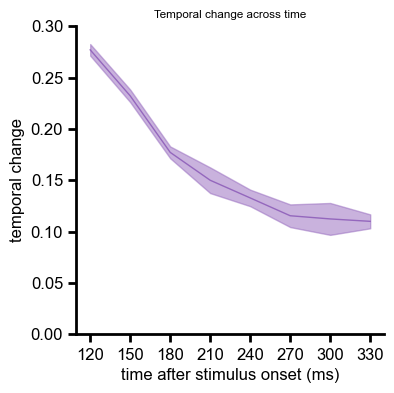

In [1]:
"""
Temporal Change Analysis for IT (Inferotemporal) Neurons

This script analyzes and visualizes temporal changes in neural correlation patterns
during visual stimulus processing. It processes pre-computed correlation metrics and
their reliability estimates to calculate how pairwise correlations change across time.

The analysis includes:
1. Loading temporal change scores from HDF5 file
2. Computing reliability-corrected correlations across neural populations
3. Identifying adaptive temporal start points for each neuron
4. Computing temporal change as the difference between correlations at different time lags
5. Generating two publication-quality plots:
    - Time series plot of median temporal change with error bands
    - Histogram comparison of early vs. late temporal changes across neurons

Key outputs:
- IT_temporal_change.pdf: Time series of temporal change across stimulus onset
- IT_temporal_change_early-late-histograms.pdf: Distribution of early vs. late temporal changes
"""

import sys
sys.path.append('../')

import h5py
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from utils.correlation_metrics import spearmanbrown_correction
from utils.plot_utils import journal_figure_pdf, journal_figure

import scienceplots

# Set matplotlib style for publication-quality figures
plt.style.use(['nature'])


# Configuration parameters
adaptive_t_start = True
scores_path = '../../scores/figure6'

all_corrs = []
all_shcs_nt = []
all_shcs_nt_next = []
all_shc_per_neuron = []

for data in os.listdir(scores_path):
    neurons_h5_file = h5py.File(os.path.join(scores_path, data), 'r')
    
    corrs = np.array(neurons_h5_file['raw_correlations'])
    shcs_nt = np.array(neurons_h5_file['shcs_nt'])
    shcs_nt_next = np.array(neurons_h5_file['shcs_nt_next'])

    all_corrs.append(corrs)
    all_shcs_nt.append(shcs_nt)
    all_shcs_nt_next.append(shcs_nt_next)

corrs = np.concatenate(all_corrs, -1)
shcs_nt = np.concatenate(all_shcs_nt, -1)
shcs_nt_next = np.concatenate(all_shcs_nt_next, -1)


# Trim data to 390ms (13 time bins)
corrs = corrs[:, :13, :13, :]
shcs_nt = shcs_nt[:, :13, :13, :]
shcs_nt_next = shcs_nt_next[:, :13, :13, :]


# Define time bins and array dimensions
t_idxs = [3, 4, 5, 6, 7, 8, 9, 10]
n_time_bins = corrs.shape[1]
n_neurons = corrs.shape[-1]

# Compute median across repetitions and correct for reliability
corrs = np.nanmedian(corrs, 0)
shcs_nt = np.nanmedian(shcs_nt, 0)
shcs_nt_next = np.nanmedian(shcs_nt_next, 0)

corrs = corrs / np.sqrt(spearmanbrown_correction(shcs_nt) * spearmanbrown_correction(shcs_nt_next))

# Initialize array to store temporal changes
delta_corrs = np.zeros((n_time_bins, n_neurons)) + np.nan

# Find adaptive time start for each neuron (first time bin with SHC > 0.4)
if adaptive_t_start:
    shc_per_neuron = shcs_nt
    t_idxs_per_neuron = np.zeros(n_neurons) + np.nan
    for n in range(n_neurons):
        for t in t_idxs:
            shc = np.nanmedian(shc_per_neuron[t, :, n])
        
            if shc > 0.4:
                t_idxs_per_neuron[n] = t
                break

# Calculate temporal change: difference between 1-bin and bin_range-bin ahead correlations
t_start = t_idxs[0]
end_time_bin_idx = 12
bin_range = 2

for n in range(n_neurons):
    if np.isnan(t_idxs_per_neuron[n]):
        continue
    if adaptive_t_start:
        t_start_ = int(t_idxs_per_neuron[n])
    else:
        t_start_ = t_start
    for t in range(t_start_, end_time_bin_idx + 1):
        if t + bin_range < corrs.shape[0]:
            delta_corrs[t, n] = corrs[t, t + 1, n] - corrs[t, t + bin_range, n]


# Extract early and late temporal change values for each neuron
curve_params = np.zeros((n_neurons, 2)) + np.nan
for n in range(n_neurons):
    t_start_ = t_idxs_per_neuron[n] if adaptive_t_start else t_start
    if np.isnan(t_start_):
        continue
    y = delta_corrs[int(t_start_):end_time_bin_idx+1-bin_range, n]
    curve_params[n, 0] = y[0]      # Early temporal change
    curve_params[n, 1] = y[-1]     # Late temporal change


discared_neurons = 0
for n in range(curve_params.shape[0]):
    if np.isnan(curve_params[n]).all():
        discared_neurons += 1
print(f"Discarded neurons with no valid temporal change values: {discared_neurons} out of {n_neurons} (total valid neurons: {n_neurons - discared_neurons})")
n_neurons -= discared_neurons

# Plot 1: Temporal change across time with error bands
median_delta_corrs = np.nanmedian(delta_corrs[t_start:end_time_bin_idx+1-bin_range], -1)
median_delta_corrs_err = np.nanstd(delta_corrs[t_start:end_time_bin_idx+1-bin_range], -1) / np.sqrt(n_neurons)
#median_delta_corrs_err = np.nanmedian(np.abs(delta_corrs[t_start:end_time_bin_idx+1-bin_range] - median_delta_corrs[:, np.newaxis]), -1)
delta_size = delta_corrs[t_start:end_time_bin_idx+1].shape[0]-bin_range

plt.figure(figsize=(5, 4))
plt.errorbar(np.arange(delta_size), 
             median_delta_corrs, 
             c='tab:purple', capsize=0, linestyle='-')
plt.fill_between(np.arange(delta_size), 
                 median_delta_corrs - median_delta_corrs_err,
                 median_delta_corrs + median_delta_corrs_err,
                 color='tab:purple', alpha=0.5)

# Format x-axis with time labels in milliseconds
start_time = t_start * 30
bin_duration = 30
labels = [start_time + ((i + 1) * bin_duration) for i in range(end_time_bin_idx + 1 - bin_range - t_start)]
range_ = list(range(len(labels)))

plt.xticks(range_, labels)
plt.xlabel("time after stimulus onset (ms)", fontsize=12)
plt.ylabel("temporal change", fontsize=12)
plt.ylim([0.0, 0.3])
plt.title("Temporal change across time", fontsize=14)

journal_figure(do_save=True, filename=f'../../plots/figure6_IT_temporal_change.eps')
journal_figure_pdf(do_save=True, filename=f'../../plots/figure6_IT_temporal_change.pdf')
plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Early temporal change median: 0.27+-0.006
Late temporal change median: 0.11+-0.007
t-test: TtestResult(statistic=np.float64(16.83072171715792), pvalue=np.float64(3.1494160299855405e-48), df=np.int64(392))


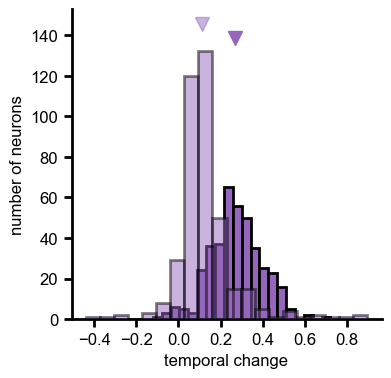

In [5]:

# Plot 2: Histogram comparing early vs. late temporal change distributions
plt.figure(figsize=(4, 5))
plt.hist(curve_params[:, 0], bins=20, color='tab:purple', edgecolor='black', linewidth=2, alpha=1.0, zorder=1)
plt.hist(curve_params[:, -1], bins=20, color='tab:purple', edgecolor='black', linewidth=2, alpha=0.5, zorder=3)

# Add median lines for early temporal change
mean_val = np.round(np.nanmedian(curve_params[:, 0]), 2)
plt.plot(mean_val, plt.ylim()[1] * 1.0, marker='v', color='tab:purple', markersize=10)
print(f"Early temporal change median: {mean_val}+-{np.round(np.nanstd(curve_params[:, 0]) / np.sqrt(n_neurons), 3)}")

# Add median lines for late temporal change
mean_val = np.round(np.nanmedian(curve_params[:, -1]), 2)
plt.plot(mean_val, plt.ylim()[1] * 1.0, marker='v', color='tab:purple', alpha=0.5, markersize=10)
print(f"Late temporal change median: {mean_val}+-{np.round(np.nanstd(curve_params[:, -1]) / np.sqrt(n_neurons),3)}")

print('t-test:', stats.ttest_rel(curve_params[:, 0], curve_params[:, -1], nan_policy='omit'))


plt.yticks(fontsize=12)
plt.xlabel(f"temporal change", fontsize=12)
plt.ylabel("number of neurons", fontsize=12)

journal_figure(do_save=True, filename=f'../../plots/figure6_IT_temporal_change_early-late-histograms.eps')
journal_figure_pdf(do_save=True, filename=f'../../plots/figure6_IT_temporal_change_early-late-histograms.pdf')
plt.show()